In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import fair
from fair.forward import fair_scm
from fair.SSPs import ssp245

# Import Scenarios
BAU = pd.read_csv("business_as_usual.csv")
moderate = pd.read_csv("moderate.csv")
progressive = pd.read_csv("progressive.csv")
reduced_meat = pd.read_csv("reduced_meat.csv")
low_emission = pd.read_csv("low_emission.csv")
plant_based = pd.read_csv("plant_based.csv")

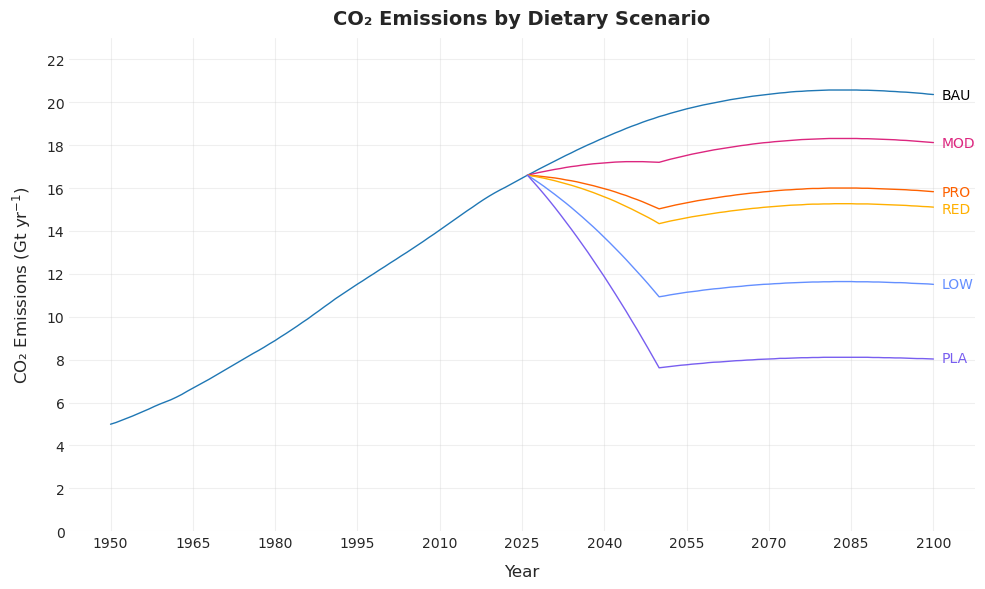

In [8]:
# ===========================
# CO2 FIGURE
# ===========================

split_year = 2026

plt.style.use("seaborn-v0_8-white")
plt.figure(figsize=(10, 6))

bau_hist_mask = (BAU["year"] >= 1950) & (BAU["year"] <= split_year)
bau_full_mask = (BAU["year"] >= 1950) & (BAU["year"] <= 2100)


# BAU 
plt.plot(
    BAU.loc[bau_full_mask, "year"],
    BAU.loc[bau_full_mask, "CO2"],
    linewidth=1
)


# SCENARIOS
scenario_info = [
    (moderate, "#DC267F", "MOD"),
    (progressive, "#FE6100", "PRO"),
    (reduced_meat, "#FFB000", "RED"),
    (low_emission, "#648FFF", "LOW"),
    (plant_based, "#785EF0", "PLA"),
]

bau_2026 = BAU.loc[BAU["year"] == split_year, ["year", "CO2"]]

for df, color, name in scenario_info:
    post = df.loc[df["year"] >= split_year + 1, ["year", "CO2"]]
    line_df = pd.concat([bau_2026, post], ignore_index=True)

    plt.plot(
        line_df["year"],
        line_df["CO2"],
        color=color,
        linewidth=1
    )


# LABELS
label_x = 2101.5

bau_2100   = BAU.loc[BAU["year"] == 2100, "CO2"].values[0]
mod_2100   = moderate.loc[moderate["year"] == 2100, "CO2"].values[0]
prog_2100  = progressive.loc[progressive["year"] == 2100, "CO2"].values[0]
red_2100   = reduced_meat.loc[reduced_meat["year"] == 2100, "CO2"].values[0]
low_2100   = low_emission.loc[low_emission["year"] == 2100, "CO2"].values[0]
plant_2100 = plant_based.loc[plant_based["year"] == 2100, "CO2"].values[0]

plt.text(label_x, bau_2100, "BAU", color="black", fontsize=10, va="center")
plt.text(label_x, mod_2100, "MOD", color="#DC267F", fontsize=10, va="center")
plt.text(label_x, prog_2100 - 0.02, "PRO", color="#FE6100", fontsize=10, va="center")
plt.text(label_x, red_2100 - 0.1, "RED", color="#FFB000", fontsize=10, va="center")
plt.text(label_x, low_2100 + 0.02, "LOW", color="#648FFF", fontsize=10, va="center")
plt.text(label_x, plant_2100 + 0.05, "PLA", color="#785EF0", fontsize=10, va="center")


# FORMATTING
plt.title("CO₂ Emissions by Dietary Scenario", fontsize=14, fontweight="bold", pad=10)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("CO₂ Emissions (Gt yr$^{-1}$)", fontsize=12, labelpad=10)

plt.xticks(np.arange(1950, 2110, 15))
plt.yticks(np.arange(0, 23, 2))
plt.ylim(0, 23)

plt.grid(True, alpha=0.3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("CO2_emissions.png", dpi=300, bbox_inches="tight")
plt.show()

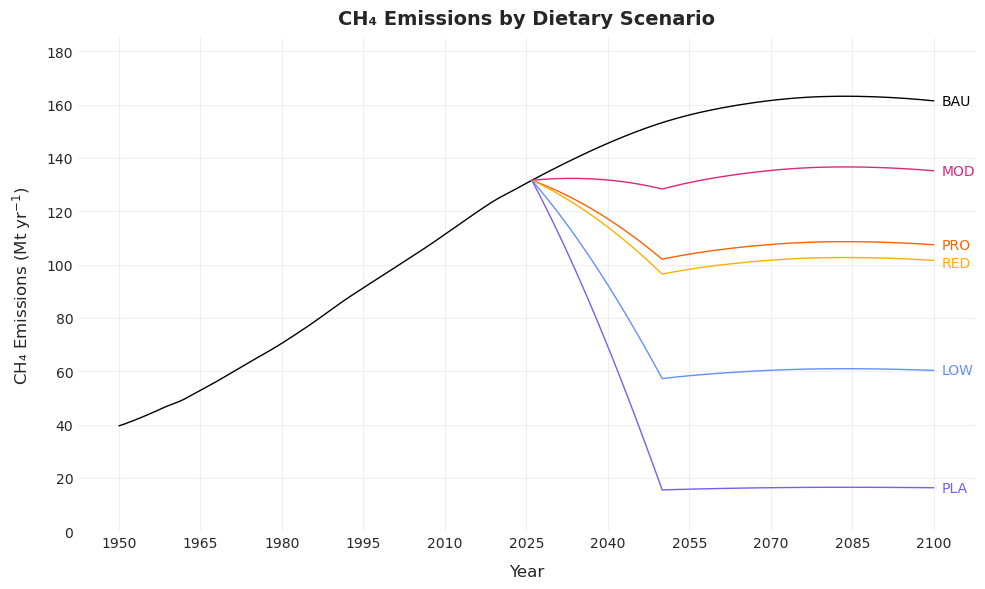

In [9]:
# ============================================================
# CH4 FIGURE
# ============================================================

split_year = 2026

plt.style.use("seaborn-v0_8-white")
plt.figure(figsize=(10, 6))

bau_hist_mask = (BAU["year"] >= 1950) & (BAU["year"] <= split_year)
bau_full_mask = (BAU["year"] >= 1950) & (BAU["year"] <= 2100)

# BAU
plt.plot(
    BAU.loc[bau_full_mask, "year"],
    BAU.loc[bau_full_mask, "CH4"],
    color="black",
    linewidth=1
)

# SCENARIOS
scenario_info = [
    (moderate, "#DC267F", "MOD"),
    (progressive, "#FE6100", "PRO"),
    (reduced_meat, "#FFB000", "RED"),
    (low_emission, "#648FFF", "LOW"),
    (plant_based, "#785EF0", "PLA"),
]

bau_2026 = BAU.loc[BAU["year"] == split_year, ["year", "CH4"]]

for df, color, name in scenario_info:
    post = df.loc[df["year"] >= split_year + 1, ["year", "CH4"]]
    line_df = pd.concat([bau_2026, post], ignore_index=True)

    plt.plot(
        line_df["year"],
        line_df["CH4"],
        color=color,
        linewidth=1
    )


# LABELS
label_x = 2101.5

bau_2100   = BAU.loc[BAU["year"] == 2100, "CH4"].values[0]
mod_2100   = moderate.loc[moderate["year"] == 2100, "CH4"].values[0]
prog_2100  = progressive.loc[progressive["year"] == 2100, "CH4"].values[0]
red_2100   = reduced_meat.loc[reduced_meat["year"] == 2100, "CH4"].values[0]
low_2100   = low_emission.loc[low_emission["year"] == 2100, "CH4"].values[0]
plant_2100 = plant_based.loc[plant_based["year"] == 2100, "CH4"].values[0]

plt.text(label_x, bau_2100, "BAU", color="black", fontsize=10, va="center")
plt.text(label_x, mod_2100 + 0.00, "MOD", color="#DC267F", fontsize=10, va="center")
plt.text(label_x, prog_2100 - 0.02, "PRO", color="#FE6100", fontsize=10, va="center")
plt.text(label_x, red_2100 - 0.8, "RED", color="#FFB000", fontsize=10, va="center")
plt.text(label_x, low_2100 + 0.02, "LOW", color="#648FFF", fontsize=10, va="center")
plt.text(label_x, plant_2100 + 0.05, "PLA", color="#785EF0", fontsize=10, va="center")


# FORMATTING
plt.title("CH₄ Emissions by Dietary Scenario", fontsize=14, fontweight="bold", pad=10)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("CH₄ Emissions (Mt yr$^{-1}$)", fontsize=12, labelpad=10)

plt.xticks(np.arange(1950, 2110, 15))
plt.yticks(np.arange(0, 185, 20))
plt.ylim(0, 185)

plt.grid(True, alpha=0.3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("CH4_emissions.png", dpi=300, bbox_inches="tight")
plt.show()

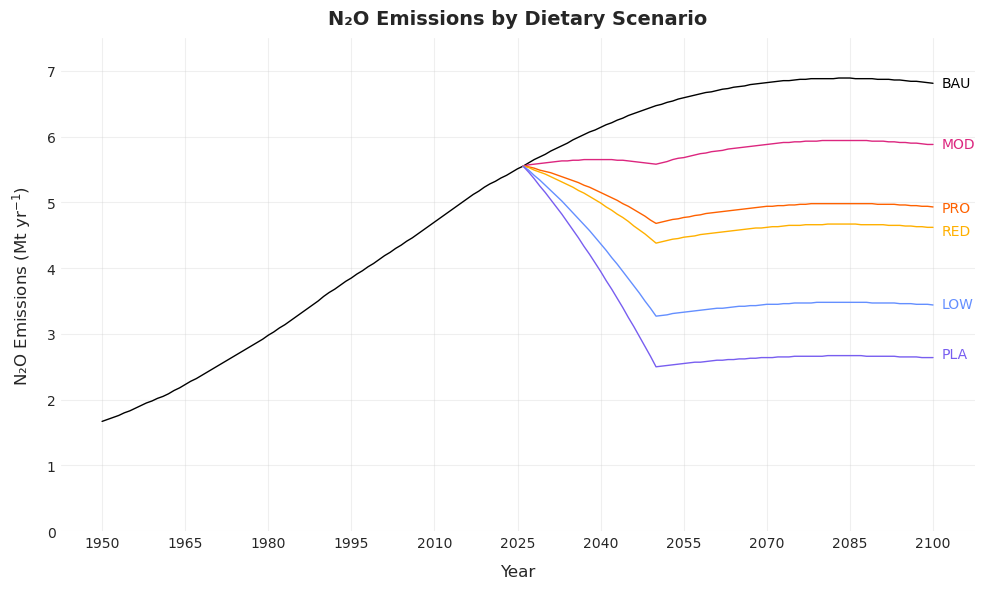

In [10]:
# ============================================================
# N2O FIGURE
# ============================================================

split_year = 2026

plt.style.use("seaborn-v0_8-white")
plt.figure(figsize=(10, 6))

# Masks
bau_hist_mask = (BAU["year"] >= 1950) & (BAU["year"] <= split_year)
bau_full_mask = (BAU["year"] >= 1950) & (BAU["year"] <= 2100)

# BAU
plt.plot(
    BAU.loc[bau_full_mask, "year"],
    BAU.loc[bau_full_mask, "N2O"],
    color="black",
    linewidth=1
)

# SCENARIOS
scenario_info = [
    (moderate, "#DC267F", "Moderate"),
    (progressive, "#FE6100", "Progressive"),
    (reduced_meat, "#FFB000", "Reduced Meat"),
    (low_emission, "#648FFF", "Low Emission"),
    (plant_based, "#785EF0", "Plant-Based"),
]

bau_2026 = BAU.loc[BAU["year"] == split_year, ["year", "N2O"]]

for df, color, name in scenario_info:
    post = df.loc[df["year"] >= split_year + 1, ["year", "N2O"]]
    line_df = pd.concat([bau_2026, post], ignore_index=True)

    plt.plot(
        line_df["year"],
        line_df["N2O"],
        color=color,
        linewidth=1
    )


# LABELS
label_x = 2101.5

bau_2100   = BAU.loc[BAU["year"] == 2100, "N2O"].values[0]
mod_2100   = moderate.loc[moderate["year"] == 2100, "N2O"].values[0]
prog_2100  = progressive.loc[progressive["year"] == 2100, "N2O"].values[0]
red_2100   = reduced_meat.loc[reduced_meat["year"] == 2100, "N2O"].values[0]
low_2100   = low_emission.loc[low_emission["year"] == 2100, "N2O"].values[0]
plant_2100 = plant_based.loc[plant_based["year"] == 2100, "N2O"].values[0]

plt.text(label_x, bau_2100, "BAU", color="black", fontsize=10, va="center")
plt.text(label_x, mod_2100 + 0.00, "MOD", color="#DC267F", fontsize=10, va="center")
plt.text(label_x, prog_2100 - 0.02, "PRO", color="#FE6100", fontsize=10, va="center")
plt.text(label_x, red_2100 - 0.05, "RED", color="#FFB000", fontsize=10, va="center")
plt.text(label_x, low_2100 + 0.02, "LOW", color="#648FFF", fontsize=10, va="center")
plt.text(label_x, plant_2100 + 0.05, "PLA", color="#785EF0", fontsize=10, va="center")


# FORMATTING
plt.title("N₂O Emissions by Dietary Scenario", fontsize=14, fontweight="bold", pad=10)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("N₂O Emissions (Mt yr$^{-1}$)", fontsize=12, labelpad=10)

plt.xticks(np.arange(1950, 2110, 15))
plt.yticks(np.arange(0, 8, 1))
plt.ylim(0, 7.5)

plt.grid(True, alpha=0.3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("N2O_emissions.png", dpi=300, bbox_inches="tight")
plt.show()

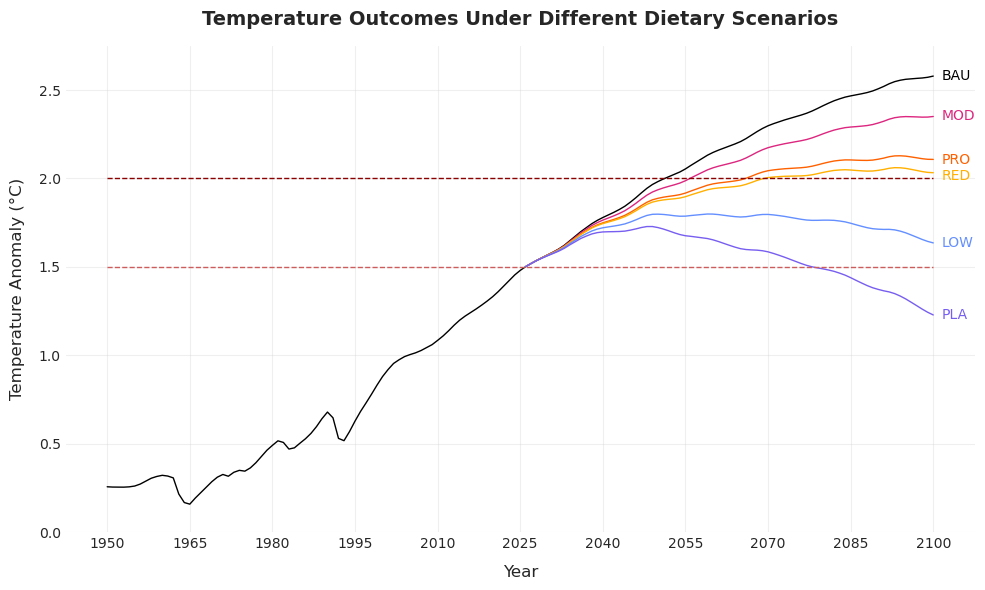

In [2]:
# ======================================
# COMBINED TEMPERATURE PROJECTION PLOT
# ======================================

# RUN SSP2-4.5 (BAU)
C245, F245, T245 = fair_scm(emissions=ssp245.Emissions.emissions)

em_bau = ssp245.Emissions.emissions.copy()
years = em_bau[:, 0].astype(int)
year_to_i = {y: i for i, y in enumerate(years)}

split_year = 2026

# BAU - DIFFERENCE
def run_scenario_bau_minus_diff(diff_file: str) -> np.ndarray:
    diff = pd.read_csv(diff_file)
    diff = diff[diff["year"].isin(years)].copy()
    idx = diff["year"].map(year_to_i).to_numpy()

    em = ssp245.Emissions.emissions.copy()

    em[idx, 1] = em[idx, 1] - diff["CO2"].to_numpy()
    em[idx, 3] = em[idx, 3] - diff["CH4"].to_numpy()
    em[idx, 4] = em[idx, 4] - diff["N2O"].to_numpy()

    C, F, T = fair_scm(emissions=em)
    return T


# RUN ALL SCENARIOS
T_mod   = run_scenario_bau_minus_diff("moderate_diff.csv")
T_prog  = run_scenario_bau_minus_diff("progressive_diff.csv")
T_red   = run_scenario_bau_minus_diff("reduced_meat_diff.csv")
T_low   = run_scenario_bau_minus_diff("low_emission_diff.csv")
T_plant = run_scenario_bau_minus_diff("plant_based_diff.csv")


# PLOT
mask_1950_2100 = (years >= 1950) & (years <= 2100)
bau_full_mask = (years >= 1950) & (years <= 2100)

plt.style.use("seaborn-v0_8-white")
plt.figure(figsize=(10, 6))

# BAU
plt.plot(
    years[bau_full_mask],
    T245[bau_full_mask],
    color="black",
    linewidth=1
)

# SCENARIOS
scenario_info = [
    (T_mod,   "#DC267F", "MOD"),
    (T_prog,  "#FE6100", "PRO"),
    (T_red,   "#FFB000", "RED"),
    (T_low,   "#648FFF", "LOW"),
    (T_plant, "#785EF0", "PLA"),
]

bau_2026_temp = T245[years == split_year][0]

for scenario, color, name in scenario_info:
    mask = (years >= split_year + 1) & (years <= 2100)

    line_years = np.concatenate(([split_year], years[mask]))
    line_temps = np.concatenate(([bau_2026_temp], scenario[mask]))

    plt.plot(
        line_years,
        line_temps,
        color=color,
        linewidth=1
    )

# THRESHOLD LINES
plt.plot([1950, 2100], [1.5, 1.5], color="indianred", linestyle="--", linewidth=1)
plt.plot([1950, 2100], [2.0, 2.0], color="darkred", linestyle="--", linewidth=1)

# LABELS
label_x = 2101.5

bau_2100   = T245[years == 2100][0]
mod_2100   = T_mod[years == 2100][0]
prog_2100  = T_prog[years == 2100][0]
red_2100   = T_red[years == 2100][0]
low_2100   = T_low[years == 2100][0]
plant_2100 = T_plant[years == 2100][0]

plt.text(label_x, bau_2100, "BAU", color="black", fontsize=10, va="center")
plt.text(label_x, mod_2100, "MOD", color="#DC267F", fontsize=10, va="center")
plt.text(label_x, prog_2100 - 0.005, "PRO", color="#FE6100", fontsize=10, va="center")
plt.text(label_x, red_2100 - 0.02, "RED",color="#FFB000", fontsize=10, va="center")
plt.text(label_x, low_2100, "LOW", color="#648FFF", fontsize=10, va="center")
plt.text(label_x, plant_2100, "PLA", color="#785EF0", fontsize=10, va="center")

# FORMATTING
plt.title("Temperature Outcomes Under Different Dietary Scenarios", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=12, labelpad=10)
plt.ylabel("Temperature Anomaly (°C)", fontsize=12, labelpad=10)

plt.xticks(np.arange(1950, 2110, 15))
plt.yticks(np.arange(0, 2.75, 0.5))
plt.ylim(0, 2.75)

plt.grid(True, alpha=0.3)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("temperature_outcomes.png", dpi=300, bbox_inches="tight")
plt.show()

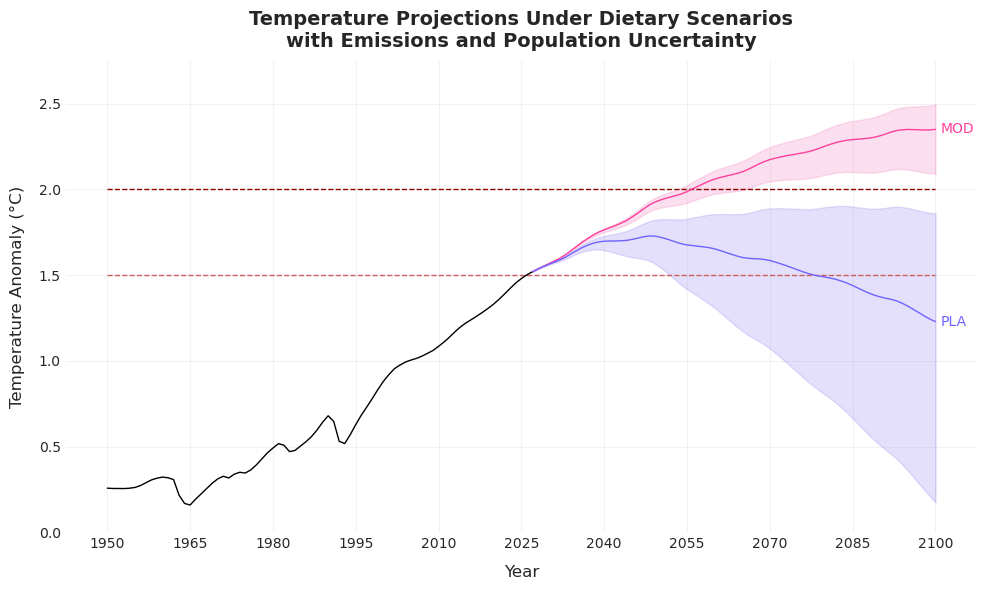

In [5]:
# ============================================================
# EMISSIONS AND POPULATION UNCERTAINTY
# ============================================================
moderate_file = "moderate_emission_uncertainty.csv"
plant_file = "plant_emission_uncertainty.csv"

title = ("Projected Global Temperature Outcomes and Uncertainty\nUnder Moderate and Plant-Based Dietary Scenarios")


# RUN BAU SSP2-4.5
em_bau = ssp245.Emissions.emissions.copy()
C245, F245, T245 = fair_scm(emissions=em_bau)

years = em_bau[:, 0].astype(int)
year_to_i = {y: i for i, y in enumerate(years)}

def load_uncertainty_csv(file):
    df = pd.read_csv(file)

    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df = df.dropna(subset=["year"]).copy()
    df["year"] = df["year"].astype(int)

    df = df[df["year"].isin(years)].copy()

    cols = ["co2low", "co2med", "co2up",
            "ch4low", "ch4med", "ch4up",
            "n2olow", "n2omed", "n2oup"]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


# RUN SCENARIO BOUNDS
def run_scenario_bound(diff_df, bound):
    em = ssp245.Emissions.emissions.copy()

    co2_col = f"co2{bound}"
    ch4_col = f"ch4{bound}"
    n2o_col = f"n2o{bound}"

    df = diff_df.dropna(subset=[co2_col, ch4_col, n2o_col], how="all").copy()
    idx = df["year"].map(year_to_i).to_numpy()

    co2_diff = df[co2_col].fillna(0).to_numpy()
    ch4_diff = df[ch4_col].fillna(0).to_numpy()
    n2o_diff = df[n2o_col].fillna(0).to_numpy()

    em[idx, 1] = em[idx, 1] - co2_diff
    em[idx, 3] = em[idx, 3] - ch4_diff
    em[idx, 4] = em[idx, 4] - n2o_diff

    C, F, T = fair_scm(emissions=em)
    return T


# LOAD DATA
moderate_df = load_uncertainty_csv(moderate_file)
plant_df = load_uncertainty_csv(plant_file)

# MODERATE SCENARIO
T_mod_low = run_scenario_bound(moderate_df, "low")
T_mod_med = run_scenario_bound(moderate_df, "med")
T_mod_up  = run_scenario_bound(moderate_df, "up")

# PLANT-BASED SCENARIO
T_plant_low = run_scenario_bound(plant_df, "low")
T_plant_med = run_scenario_bound(plant_df, "med")
T_plant_up  = run_scenario_bound(plant_df, "up")

# MAKE UNCERTAINTY BOUNDS
mod_lower = np.minimum(T_mod_low, T_mod_up)
mod_upper = np.maximum(T_mod_low, T_mod_up)

plant_lower = np.minimum(T_plant_low, T_plant_up)
plant_upper = np.maximum(T_plant_low, T_plant_up)

# PLOT
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(10, 6))

for spine in ax.spines.values():
    spine.set_visible(False)

# SSP2-4.5 <2027
bau_mask = (years >= 1950) & (years <= 2027)
ax.plot(years[bau_mask], T245[bau_mask], color="black", linewidth=1, zorder=4)

# SCENARIO >2027
scen_mask = (years >= 2027) & (years <= 2100)

# MODERATE 
ax.fill_between(
    years[scen_mask],
    mod_lower[scen_mask],
    mod_upper[scen_mask],
    color="#f062b0",
    alpha=0.20,
    zorder=2
)
ax.plot(
    years[scen_mask],
    T_mod_med[scen_mask],
    color="#ff3f9a",
    linewidth=1,
    zorder=5
)

# PLANT-BASED
ax.fill_between(
    years[scen_mask],
    plant_lower[scen_mask],
    plant_upper[scen_mask],
    color="#7b68ee",
    alpha=0.20,
    zorder=2
)
ax.plot(
    years[scen_mask],
    T_plant_med[scen_mask],
    color="#6f63ff",
    linewidth=1,
    zorder=5
)

# THRESHOLD LINES
plt.plot([1950, 2100], [1.5, 1.5], color="indianred", linestyle="--", linewidth=1)
plt.plot([1950, 2100], [2.0, 2.0], color="darkred", linestyle="--", linewidth=1)

# LABELS
ax.set_title(
    "Temperature Projections Under Dietary Scenarios\nwith Emissions and Population Uncertainty",
    fontsize=14, fontweight="bold", pad=10)

ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.set_ylabel("Temperature Anomaly (°C)", fontsize=12, labelpad=10)
ax.grid(alpha=0.25)

x_end = 2100
ix_end = np.where(years == x_end)[0]
if ix_end.size == 0:
    raise RuntimeError(f"x_end={x_end} not found in FaIR years vector.")
ix_end = int(ix_end[0])

x_label = x_end + 1

endpoints = [
    ["MOD", "#ff3f9a", float(T_mod_med[ix_end])],
    ["PLA", "#6f63ff", float(T_plant_med[ix_end])]
]

endpoints.sort(key=lambda x: x[2])
min_dy = 0.07
for i in range(1, len(endpoints)):
    if endpoints[i][2] - endpoints[i - 1][2] < min_dy:
        endpoints[i][2] = endpoints[i - 1][2] + min_dy

for label, color, y_lab in endpoints:
    ax.text(x_label, y_lab, label, color=color, fontsize=10, va="center")

plt.xticks(np.arange(1950, 2110, 15))
plt.yticks(np.arange(0, 3.5, 0.5))
plt.ylim(0, 2.75)

plt.tight_layout()
plt.savefig("emission_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

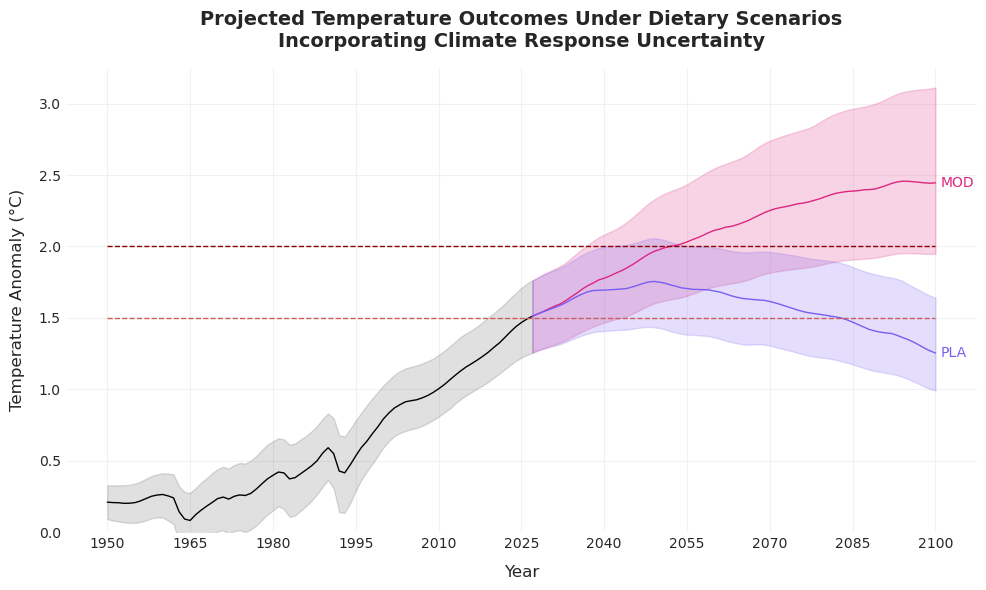

In [4]:
# ============================================================
# TEMPERATURE UNCERTAINTY PLOT
# ============================================================

import warnings
from scipy import stats
from fair.tools.ensemble import tcrecs_generate
from fair.tools.constrain import hist_temp

n_ens = 600
use_constraint = True
igcc_path = "global_climate_indicators.csv"

# COLOURS
c_mod   = "#DC267F"
c_plant = "#785EF0"
c_bau   = "black"

# TIMEFRAME
start_year_plot = 1950
start_year_scen = 2027
end_year_plot   = 2100

# LOAD SSP2-4.5 BASELINE
em_bau = ssp245.Emissions.emissions.copy()
years = em_bau[:, 0].astype(int)
year_to_i = {y: i for i, y in enumerate(years)}

mask_1950_2100 = (years >= start_year_plot) & (years <= end_year_plot)
pre_mask       = (years >= start_year_plot) & (years <= start_year_scen)
post_mask      = (years >= start_year_scen) & (years <= end_year_plot)

# BUILD SCENARIO EMISSIONS (BAU - DIFF)
def build_emissions_bau_minus_diff(diff_file: str) -> np.ndarray:
    diff = pd.read_csv(diff_file)

    required = {"year", "CO2", "CH4", "N2O"}
    if not required.issubset(set(diff.columns)):
        raise ValueError(
            f"{diff_file} must contain columns {required}. Found {set(diff.columns)}"
        )

    diff = diff[(diff["year"] >= start_year_scen) & (diff["year"].isin(years))].copy()
    if diff.empty:
        raise ValueError(f"{diff_file} has no overlapping years with SSP baseline from {start_year_scen} onwards.")

    idx = diff["year"].map(year_to_i).to_numpy()

    em = em_bau.copy()
    em[idx, 1] = em[idx, 1] - diff["CO2"].to_numpy()
    em[idx, 3] = em[idx, 3] - diff["CH4"].to_numpy()
    em[idx, 4] = em[idx, 4] - diff["N2O"].to_numpy()
    return em

em_mod   = build_emissions_bau_minus_diff("moderate_diff.csv")
em_plant = build_emissions_bau_minus_diff("plant_based_diff.csv")

# LOAD OBSERVATIONS
if use_constraint:
    igcc = pd.read_csv(igcc_path)

    if "time" not in igcc.columns:
        raise ValueError(f"{igcc_path} must contain 'time' column. Found {list(igcc.columns)}")

    if "GMST" in igcc.columns:
        gmst_col = "GMST"
    elif "gmst" in igcc.columns:
        gmst_col = "gmst"
    else:
        raise ValueError(f"{igcc_path} must contain 'GMST' or 'gmst'. Found {list(igcc.columns)}")

    obs_years = igcc["time"].to_numpy().astype(int)
    obs_gmst  = igcc[gmst_col].to_numpy().astype(float)

# ENSEMBLE GENERATION
tcrecs_ens = tcrecs_generate(
    "cmip5",
    n=n_ens,
    dist="lognorm",
    correlated=True,
    seed=38571
)

# PARAMETER UNCERTAINTY
F_aeroscale = stats.norm.rvs(size=n_ens, loc=1.0, scale=0.65, random_state=1)

r0 = stats.norm.rvs(size=n_ens, loc=35.0,  scale=3.5,    random_state=2)
rc = stats.norm.rvs(size=n_ens, loc=0.019, scale=0.0019, random_state=3)
rt = stats.norm.rvs(size=n_ens, loc=4.165, scale=0.4165, random_state=4)

d2 = stats.norm.rvs(size=n_ens, loc=239.0, scale=63.0, random_state=5)
d1 = stats.norm.rvs(size=n_ens, loc=4.1,   scale=1.0,  random_state=6)

# CLIP EXTREMES
d1 = np.clip(d1, 0.5, 10.0)
d2 = np.clip(d2, 50.0, 500.0)
r0 = np.clip(r0, 10.0, 80.0)
rc = np.clip(rc, 0.005, 0.05)
rt = np.clip(rt, 0.5, 10.0)

# RUN ENSEMBLE
def run_ensemble_safe(emissions: np.ndarray) -> np.ndarray:
    """
    Returns T_ens with shape (n_years, n_members_kept).
    If use_constraint=True, applies historical temperature constraint via hist_temp.
    """
    n_years = len(years)
    T_all = np.full((n_years, n_ens), np.nan, dtype=float)

    for i in range(n_ens):
        scale = np.ones(13)
        scale[8] = F_aeroscale[i]

        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("error", category=RuntimeWarning)

                _, _, Ti = fair_scm(
                    emissions=emissions,
                    tcrecs=tcrecs_ens[i],
                    r0=r0[i], rc=rc[i], rt=rt[i],
                    scale=scale,
                    d=np.array([d1[i], d2[i]])
                )

            if np.all(np.isfinite(Ti)):
                T_all[:, i] = Ti

        except (RuntimeWarning, FloatingPointError, OverflowError, ValueError):
            continue

    ok = np.all(np.isfinite(T_all), axis=0)
    T_ok = T_all[:, ok]

    if T_ok.shape[1] < 50:
        raise RuntimeError(f"Too few valid members after filtering: {T_ok.shape[1]} / {n_ens}")

    if not use_constraint:
        return T_ok

    # APPLY OBSERVATIONAL CONSTRAINT
    common_years = np.intersect1d(obs_years, years)
    common_years = common_years[common_years >= 1880]

    if common_years.size < 50:
        raise RuntimeError("Too few overlapping years between observations and model for constraint.")

    obs_mask = np.isin(obs_years, common_years)
    obs_y = obs_years[obs_mask]
    obs_t = obs_gmst[obs_mask]

    order = np.argsort(obs_y)
    obs_y = obs_y[order]
    obs_t = obs_t[order]

    model_mask = np.isin(years, common_years)

    if obs_t.shape[0] != np.count_nonzero(model_mask):
        raise RuntimeError(
            f"Obs/model alignment failed: obs={obs_t.shape[0]} vs model={np.count_nonzero(model_mask)}. "
            "Check annual_averages.csv year coverage."
        )

    keep = np.zeros(T_ok.shape[1], dtype=bool)
    for j in range(T_ok.shape[1]):
        keep[j], *_ = hist_temp(obs_t, T_ok[model_mask, j], obs_y)

    T_keep = T_ok[:, keep]

    if T_keep.shape[1] < 30:
        raise RuntimeError(f"Too few members after observational constraint: {T_keep.shape[1]}")

    return T_keep

# RUN ENSEMBLES
T_bau_ens   = run_ensemble_safe(em_bau)
T_mod_ens   = run_ensemble_safe(em_mod)
T_plant_ens = run_ensemble_safe(em_plant)

# PERCENTILE BANDS
bau_p25, bau_p50, bau_p975 = np.nanpercentile(T_bau_ens,   [2.5, 50, 97.5], axis=1)
mod_p25, mod_p50, mod_p975 = np.nanpercentile(T_mod_ens,   [2.5, 50, 97.5], axis=1)
pl_p25,  pl_p50,  pl_p975  = np.nanpercentile(T_plant_ens, [2.5, 50, 97.5], axis=1)

# PLOT
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(10, 6))

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# SSP2-4.5 <2027
ax.fill_between(years[pre_mask], bau_p25[pre_mask], bau_p975[pre_mask], color=c_bau, alpha=0.12)
ax.plot(years[pre_mask], bau_p50[pre_mask], color=c_bau, linewidth=1, label="BAU (SSP2-4.5)")

# SCENARIO UNCERTANTY >2027
ax.fill_between(years[post_mask], mod_p25[post_mask], mod_p975[post_mask], color=c_mod, alpha=0.20)
ax.plot(years[post_mask], mod_p50[post_mask], color=c_mod, linewidth=1, label="MOD")

ax.fill_between(years[post_mask], pl_p25[post_mask], pl_p975[post_mask], color=c_plant, alpha=0.20)
ax.plot(years[post_mask], pl_p50[post_mask], color=c_plant, linewidth=1, label="PLA")

# THRESHOLD LINES
ax.hlines(1.5, xmin=start_year_plot, xmax=end_year_plot, colors="indianred", linestyles="--", linewidth=1)
ax.hlines(2.0, xmin=start_year_plot, xmax=end_year_plot, colors="darkred",   linestyles="--", linewidth=1)

# LABELS
ax.set_title("Projected Temperature Outcomes Under Dietary Scenarios\nIncorporating Climate Response Uncertainty", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.set_ylabel("Temperature Anomaly (°C)", fontsize=12, labelpad=10)
ax.grid(alpha=0.25)

x_end = end_year_plot
ix_end = np.where(years == x_end)[0]
if ix_end.size == 0:
    raise RuntimeError(f"end_year_plot={end_year_plot} not found in FaIR years vector.")
ix_end = int(ix_end[0])

x_label = end_year_plot + 1
endpoints = [["MOD",   c_mod,   float(mod_p50[ix_end])],["PLA", c_plant, float(pl_p50[ix_end])]]
endpoints.sort(key=lambda x: x[2])
min_dy = 0.07
for i in range(1, len(endpoints)):
    if endpoints[i][2] - endpoints[i-1][2] < min_dy:
        endpoints[i][2] = endpoints[i-1][2] + min_dy

for label, color, y_lab in endpoints:
    ax.text(x_label, y_lab, label, color=color, fontsize=10, va="center")

plt.xticks(np.arange(1950, 2110, 15))
plt.yticks(np.arange(0, 3.6, 0.5))
plt.ylim(0, 3.7)

plt.tight_layout()
plt.savefig("climate_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

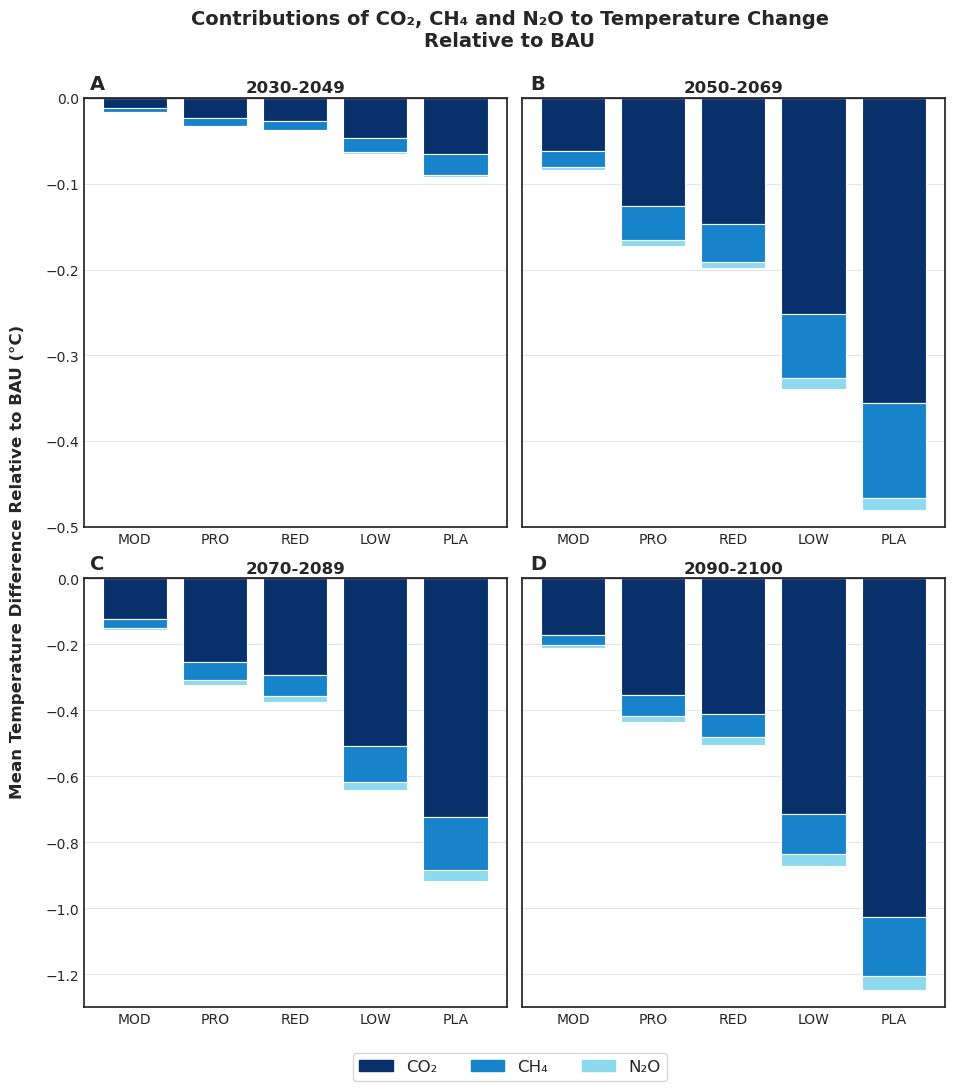

In [6]:
# =========================================================================
# TEMPERATURE CHANGE RELATIVE TO BAU AND GHG CONTRIBUTION
# =========================================================================

plt.style.use("seaborn-v0_8-white")

time_periods = {
    "2030-2049": (2030, 2049),
    "2050-2069": (2050, 2069),
    "2070-2089": (2070, 2089),
    "2090-2100": (2090, 2100),
}

scenario_files = {
    "MOD": "moderate_diff.csv",
    "PRO": "progressive_diff.csv",
    "RED": "reduced_meat_diff.csv",
    "LOW": "low_emission_diff.csv",
    "PLA": "plant_based_diff.csv",
}

gases = ["CO2", "CH4", "N2O"]
bar_w = 0.8

# BAU
em_bau = ssp245.Emissions.emissions.copy()
years = em_bau[:, 0].astype(int)
year_to_i = {y: i for i, y in enumerate(years)}

_, _, T_bau = fair_scm(emissions=em_bau)

def run_T(em):
    _, _, T = fair_scm(emissions=em)
    return T

def apply_diff(diff_file, gases_to_apply):
    em = ssp245.Emissions.emissions.copy()
    diff = pd.read_csv(diff_file)
    diff = diff[diff["year"].isin(years)].copy()
    idx = diff["year"].map(year_to_i).to_numpy()

    if "CO2" in gases_to_apply:
        em[idx, 1] -= diff["CO2"].to_numpy()
    if "CH4" in gases_to_apply:
        em[idx, 3] -= diff["CH4"].to_numpy()
    if "N2O" in gases_to_apply:
        em[idx, 4] -= diff["N2O"].to_numpy()

    return em

def period_mean(arr, start, end):
    m = (years >= start) & (years <= end)
    return float(np.mean(arr[m]))


# CALCULATE CHANGE BY GAS
rows = []
for scen, file in scenario_files.items():
    dT_gas = {}
    for g in gases:
        T_g = run_T(apply_diff(file, (g,)))
        dT_gas[g] = T_g - T_bau

    for per, (s, e) in time_periods.items():
        rows.append({
            "Scenario": scen,
            "Period": per,
            "CO2": period_mean(dT_gas["CO2"], s, e),
            "CH4": period_mean(dT_gas["CH4"], s, e),
            "N2O": period_mean(dT_gas["N2O"], s, e),
        })

df = pd.DataFrame(rows)


# PLOT
period_order = list(time_periods.keys())
scenario_order = list(scenario_files.keys())

fig, axes = plt.subplots(2, 2, figsize=(10, 12), sharey="row")

axes = axes.flatten()
plt.subplots_adjust(hspace=5)
fig.supylabel(
    "Mean Temperature Difference Relative to BAU (°C)",
    fontsize=12,
    fontweight="bold",
    x=0.05
)

gas_colors = {
    "CO2": "#08306b",
    "CH4": "#1683CA",
    "N2O": "#8DDAEF"
}

for ax, per in zip(axes, period_order):
    sub = df[df["Period"] == per].set_index("Scenario").loc[scenario_order]

    x = np.arange(len(scenario_order))
    pos_bottom = np.zeros(len(x))
    neg_bottom = np.zeros(len(x))

    for g in ["CO2", "CH4", "N2O"]:
        vals = sub[g].to_numpy()
        pos = np.where(vals > 0, vals, 0.0)
        neg = np.where(vals < 0, vals, 0.0)

        ax.bar(
            x, pos,
            width=bar_w,
            bottom=pos_bottom,
            color=gas_colors[g],
            edgecolor="white",
            linewidth=0.8
        )
        ax.bar(
            x, neg,
            width=bar_w,
            bottom=neg_bottom,
            color=gas_colors[g],
            edgecolor="white",
            linewidth=0.8
        )

        pos_bottom += pos
        neg_bottom += neg

    ax.axhline(0, color="#333333", linewidth=0.9)
    ax.set_title(per, fontsize=12, fontweight="bold", pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_order, fontsize=10)
    ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)

# set y-limits
for ax in axes[:2]:
    ax.set_ylim(-0.5, 0)

for ax in axes[2:]:
    ax.set_ylim(-1.3, 0)

# PANEL LABELS
panel_positions = {
    "A": (0.13, 0.89),
    "B": (0.57, 0.89),
    "C": (0.13, 0.49),
    "D": (0.57, 0.49),
}

for label, (x_pos, y_pos) in panel_positions.items():
    fig.text(
        x_pos, y_pos, label,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="bottom"
    )

fig.suptitle(
    "Contributions of CO₂, CH₄ and N₂O to Temperature Change\nRelative to BAU",
    fontsize=14, fontweight="bold", y=0.96, x=0.55)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=gas_colors[g])
    for g in ["CO2", "CH4", "N2O"]
]
fig.legend(
    handles,
    ["CO₂", "CH₄", "N₂O"],
    loc="lower center",
    fontsize=12,
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.55, 0.06)
)

plt.tight_layout(rect=[0.04, 0.10, 1, 0.96])
plt.savefig("gas_contribution.png", dpi=300, bbox_inches="tight")
plt.show()